# Startup Investment Outcome — Feature Selection & Modeling

**Input:** `data/train_resampled.csv`, `data/val_processed.csv`, `data/test_processed.csv`  
**Goal:** Select the most informative features using statistical tests and model-based importance methods, then train and compare multiple classifiers with regularization, selecting the best model for final evaluation on the test set.  
**Note:** All feature selection is fit on the **training set only**. Validation and test sets are transformed, never used to fit selectors.

This notebook follows the same structure as `04_Imbalanced_Data.ipynb`.  
Each section ends with a **→ Modeling Decision** box.

**Pipeline position:**
```
01_EDA → 02_... → 03_Preprocessing → 04_Imbalanced_Data → [05_Feature_Selection_Modeling] ← you are here
```

## 0. Imports & Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Feature selection
from sklearn.feature_selection import (
    SelectKBest, f_classif, chi2,
    SelectFromModel, SequentialFeatureSelector
)

# Models
from sklearn.linear_model import LogisticRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

# Evaluation
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score,
    roc_curve, auc, classification_report
)
from sklearn.preprocessing import label_binarize

# Permutation importance
from sklearn.inspection import permutation_importance

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)

STATUS_MAP   = {0: 'closed', 1: 'operating', 2: 'acquired'}
STATUS_NAMES = ['closed', 'operating', 'acquired']
COLORS       = ['#FF5722', '#2196F3', '#4CAF50']
RANDOM_STATE = 42

## 1. Load Data

The processed CSVs come from `03_Preprocessing.ipynb`. Key point: `FundingLogTransformer` creates `log_<col>` versions of all 14 funding amount columns **but does not drop the originals** — they remain in the CSV.

We must drop the raw funding columns here so the model only sees the log-transformed features, which are on a comparable scale and avoid the heavy right-skew of the raw dollar amounts.

| Raw column (DROP) | Log column (KEEP) |
|-------------------|-------------------|
| `funding_total_usd` | `log_funding_total_usd` |
| `seed`, `venture`, `angel`, … | `log_seed`, `log_venture`, `log_angel`, … |
| *(14 total)* | *(14 total, via `np.log1p`)* |

In [4]:
train = pd.read_csv('data/train_resampled.csv')
val   = pd.read_csv('data/val_processed.csv')
test  = pd.read_csv('data/test_processed.csv')

# ── Drop columns not used for modeling ────────────────────────────────────
# geo_cluster: non-numeric cluster label (kept for EDA reference in 03_Preprocessing)
# Raw funding columns: 03_Preprocessing applies log1p via FundingLogTransformer,
# producing log_<col> versions. The originals are left in the CSV but must NOT
# be fed to the model — using both raw + log would introduce redundancy and
# let the model bypass the intended transformation.
RAW_FUNDING_COLS = [
    'funding_total_usd', 'seed', 'venture', 'angel', 'grant',
    'private_equity', 'debt_financing', 'equity_crowdfunding',
    'convertible_note', 'undisclosed', 'product_crowdfunding',
    'post_ipo_equity', 'post_ipo_debt', 'secondary_market',
]

DROP_COLS = ['status_code', 'geo_cluster'] + RAW_FUNDING_COLS

def prepare_X(df):
    cols_to_drop = [c for c in DROP_COLS if c in df.columns]
    return df.drop(columns=cols_to_drop)

X_train = prepare_X(train)
y_train = train['status_code']

X_val   = prepare_X(val)
y_val   = val['status_code']

X_test  = prepare_X(test)
y_test  = test['status_code']

# Verify log_ columns are present and raw columns are gone
log_funding_cols   = [c for c in X_train.columns if c.startswith('log_')]
raw_still_present  = [c for c in RAW_FUNDING_COLS if c in X_train.columns]
print(f"Train (resampled): {X_train.shape}  |  Val: {X_val.shape}  |  Test: {X_test.shape}")
print(f"\nLog-transformed funding features ({len(log_funding_cols)}): {log_funding_cols}")
print(f"Raw funding cols remaining (should be 0): {raw_still_present}")
print(f"\nAll features ({len(X_train.columns)}):")
print(list(X_train.columns))
print(f"\nClass distribution (train):")
for k, cnt in y_train.value_counts().sort_index().items():
    print(f"  {k} ({STATUS_MAP[k]:>10s}): {cnt:,}  ({cnt/len(y_train)*100:.1f}%)")

Train (resampled): (62358, 30)  |  Val: (5971, 30)  |  Test: (5971, 30)

Log-transformed funding features (14): ['log_funding_total_usd', 'log_seed', 'log_venture', 'log_angel', 'log_grant', 'log_private_equity', 'log_debt_financing', 'log_equity_crowdfunding', 'log_convertible_note', 'log_undisclosed', 'log_product_crowdfunding', 'log_post_ipo_equity', 'log_post_ipo_debt', 'log_secondary_market']
Raw funding cols remaining (should be 0): []

All features (30):
['funding_rounds', 'round_A', 'round_B', 'round_C', 'founded_year', 'founded_month', 'founded_quarter', 'log_funding_total_usd', 'log_seed', 'log_venture', 'log_angel', 'log_grant', 'log_private_equity', 'log_debt_financing', 'log_equity_crowdfunding', 'log_convertible_note', 'log_undisclosed', 'log_product_crowdfunding', 'log_post_ipo_equity', 'log_post_ipo_debt', 'log_secondary_market', 'has_round_A', 'has_round_B', 'has_round_C', 'round_D_plus', 'days_to_first_funding', 'market_enc_acquired', 'market_enc_closed', 'country_cod

## 2. Evaluation Helper

Reuse the same helper pattern from `04_Imbalanced_Data.ipynb` — consistent metrics across all notebooks.

In [5]:
def classification_metrics(y_true, y_pred, model_name=''):
    """Return a metrics dict for multiclass classification."""
    per_class = f1_score(y_true, y_pred, average=None, labels=[0, 1, 2])
    return {
        'Model':        model_name,
        'Accuracy':     accuracy_score(y_true, y_pred),
        'Macro F1':     f1_score(y_true, y_pred, average='macro'),
        'Weighted F1':  f1_score(y_true, y_pred, average='weighted'),
        'F1 closed':    per_class[0],
        'F1 operating': per_class[1],
        'F1 acquired':  per_class[2],
    }


def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix', ax=None):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=STATUS_NAMES, yticklabels=STATUS_NAMES, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    if ax is None:
        plt.tight_layout()
        plt.show()

---
# Part A — Feature Selection

We apply three complementary families of feature selection and aggregate their votes.

| Family | Methods |
|--------|---------|
| **Statistical (filter)** | ANOVA F-test, Chi-squared |
| **Model importance (wrapper)** | Random Forest, Gradient Boosting, Lasso, Ridge, Linear SVM |
| **Sequential wrapper** | Forward Selection (Random Forest base) |
| **Post-hoc** | Permutation Importance |

## 3. Statistical Feature Selection (Filter Methods)

Filter methods rank features **independently of any model**, using statistical tests to measure the relationship between each feature and the target.

### 3.1 ANOVA F-test (`f_classif`)

**ANOVA (Analysis of Variance)** tests whether the group means (per class) of a feature differ significantly.  
- High F-value → large variance *between* classes relative to variance *within* classes → feature discriminates well.  
- Low p-value → we can reject the null hypothesis that all class means are equal.

In [6]:
f_values, p_values = f_classif(X_train, y_train)

anova_df = pd.DataFrame({
    'Feature': X_train.columns,
    'F-Value': f_values,
    'P-Value': p_values
}).sort_values('F-Value', ascending=False).reset_index(drop=True)

print("ANOVA F-test results (sorted by F-value):")
display(anova_df.round(4))

ANOVA F-test results (sorted by F-value):


,Feature,F-Value,P-Value
0,log_funding_total_usd,5213.8644,0.0000
1,market_enc_acquired,3555.2973,0.0000
2,log_venture,3365.2486,0.0000
3,market_enc_closed,3294.2923,0.0000
4,has_round_B,1787.4040,0.0000
5,country_code_enc_acquired,1678.8132,0.0000
6,funding_rounds,1557.0862,0.0000
7,has_round_C,1519.9760,0.0000
8,founded_year,1159.2753,0.0000
9,has_round_A,1005.8123,0.0000


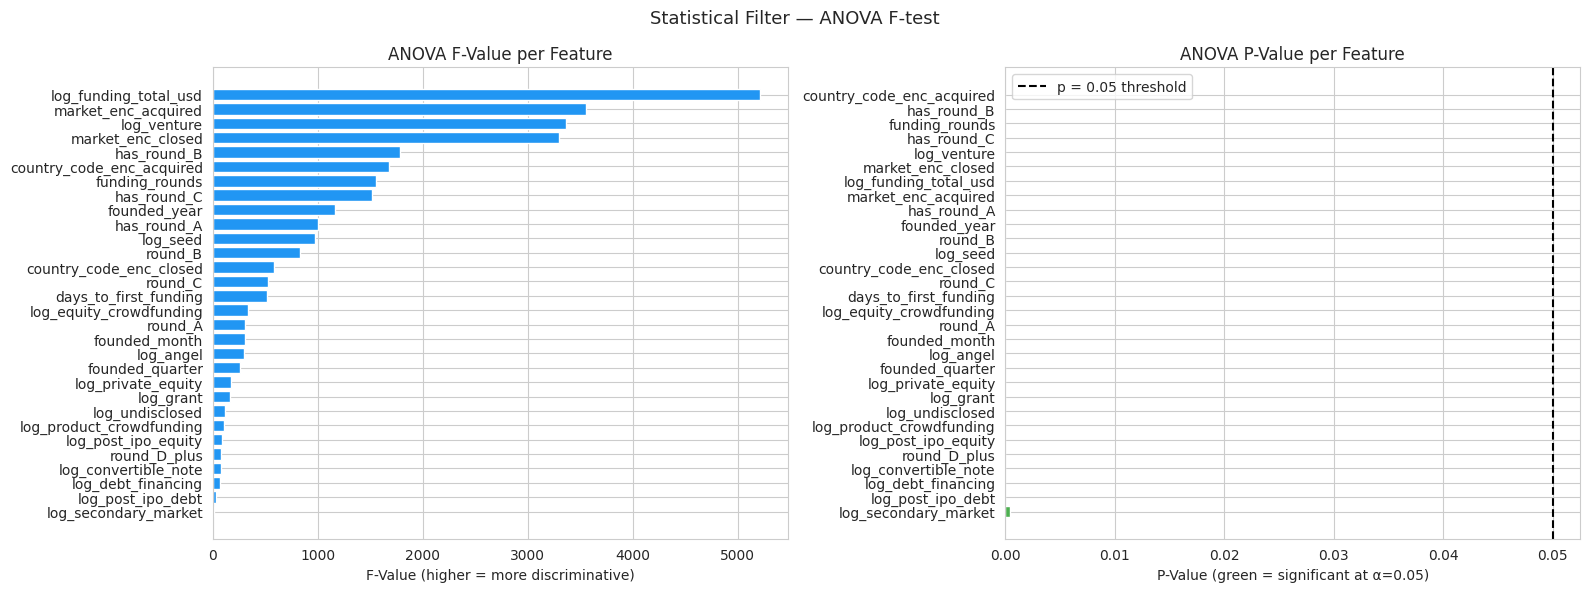


Features significant at α=0.05 (30): ['log_funding_total_usd', 'market_enc_acquired', 'log_venture', 'market_enc_closed', 'has_round_B', 'country_code_enc_acquired', 'funding_rounds', 'has_round_C', 'founded_year', 'has_round_A', 'log_seed', 'round_B', 'country_code_enc_closed', 'round_C', 'days_to_first_funding', 'log_equity_crowdfunding', 'round_A', 'founded_month', 'log_angel', 'founded_quarter', 'log_private_equity', 'log_grant', 'log_undisclosed', 'log_product_crowdfunding', 'log_post_ipo_equity', 'round_D_plus', 'log_convertible_note', 'log_debt_financing', 'log_post_ipo_debt', 'log_secondary_market']


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# F-values bar chart
sorted_f = anova_df.sort_values('F-Value', ascending=True)
axes[0].barh(sorted_f['Feature'], sorted_f['F-Value'], color='#2196F3', edgecolor='white')
axes[0].set_title('ANOVA F-Value per Feature')
axes[0].set_xlabel('F-Value (higher = more discriminative)')

# P-values bar chart with significance line
sorted_p = anova_df.sort_values('P-Value', ascending=False)
bar_colors = ['#4CAF50' if p < 0.05 else '#FF5722' for p in sorted_p['P-Value']]
axes[1].barh(sorted_p['Feature'], sorted_p['P-Value'], color=bar_colors, edgecolor='white')
axes[1].axvline(0.05, color='black', linestyle='--', label='p = 0.05 threshold')
axes[1].set_title('ANOVA P-Value per Feature')
axes[1].set_xlabel('P-Value (green = significant at α=0.05)')
axes[1].legend()

plt.suptitle('Statistical Filter — ANOVA F-test', fontsize=13)
plt.tight_layout()
plt.show()

# Features significant at alpha = 0.05
anova_significant = anova_df[anova_df['P-Value'] < 0.05]['Feature'].tolist()
print(f"\nFeatures significant at α=0.05 ({len(anova_significant)}): {anova_significant}")

### 3.2 Chi-Squared Test (`chi2`)

Chi-squared tests the independence between each (non-negative) feature and the target.  
- Requires **non-negative** feature values — applicable to our scaled/encoded features that are ≥ 0.
- High χ² statistic → feature and target are strongly associated.

In [8]:
# Shift features to be non-negative for chi2
X_train_nonneg = X_train - X_train.min()

chi2_values, chi2_p = chi2(X_train_nonneg, y_train)

chi2_df = pd.DataFrame({
    'Feature':  X_train.columns,
    'Chi2':     chi2_values,
    'P-Value':  chi2_p
}).sort_values('Chi2', ascending=False).reset_index(drop=True)

print("Chi-Squared test results (sorted by Chi2 statistic):")
display(chi2_df.round(4))

chi2_significant = chi2_df[chi2_df['P-Value'] < 0.05]['Feature'].tolist()
print(f"\nFeatures significant at α=0.05 ({len(chi2_significant)}): {chi2_significant}")

Chi-Squared test results (sorted by Chi2 statistic):


,Feature,Chi2,P-Value
0,round_B,3.739822e+10,0.0000
1,round_C,3.404045e+10,0.0000
2,round_D_plus,1.959424e+10,0.0000
3,round_A,8.907714e+09,0.0000
4,days_to_first_funding,1.011541e+06,0.0000
5,log_venture,3.553786e+04,0.0000
6,log_seed,1.610441e+04,0.0000
7,log_equity_crowdfunding,7.590213e+03,0.0000
8,log_angel,6.742140e+03,0.0000
9,funding_rounds,5.942582e+03,0.0000



Features significant at α=0.05 (30): ['round_B', 'round_C', 'round_D_plus', 'round_A', 'days_to_first_funding', 'log_venture', 'log_seed', 'log_equity_crowdfunding', 'log_angel', 'funding_rounds', 'log_private_equity', 'log_grant', 'log_funding_total_usd', 'log_undisclosed', 'log_post_ipo_equity', 'has_round_B', 'founded_month', 'has_round_C', 'log_product_crowdfunding', 'log_convertible_note', 'log_debt_financing', 'has_round_A', 'log_post_ipo_debt', 'founded_quarter', 'founded_year', 'market_enc_acquired', 'market_enc_closed', 'log_secondary_market', 'country_code_enc_acquired', 'country_code_enc_closed']


In [10]:
# SelectKBest — top K features by ANOVA
K = min(20, len(X_train.columns))
selector_anova = SelectKBest(score_func=f_classif, k=K)
selector_anova.fit(X_train, y_train)

anova_top_k = X_train.columns[selector_anova.get_support()].tolist()
print(f"Top {K} features by ANOVA SelectKBest: {anova_top_k}")

# Binary selection mask for voting (1 if in top K)
anova_selected = selector_anova.get_support().astype(int)

Top 20 features by ANOVA SelectKBest: ['funding_rounds', 'round_A', 'round_B', 'round_C', 'founded_year', 'founded_month', 'founded_quarter', 'log_funding_total_usd', 'log_seed', 'log_venture', 'log_angel', 'log_equity_crowdfunding', 'has_round_A', 'has_round_B', 'has_round_C', 'days_to_first_funding', 'market_enc_acquired', 'market_enc_closed', 'country_code_enc_acquired', 'country_code_enc_closed']


> **→ Modeling Decision (Filter Methods):** Features with low ANOVA p-values and high chi-squared statistics are strong individual predictors. These filters are fast and model-agnostic, but they don't capture interactions — we use them as one vote in the ensemble.

## 4. Correlation Analysis

Highly correlated features carry redundant information. We remove one from each highly correlated pair to reduce multicollinearity before model-based selection.

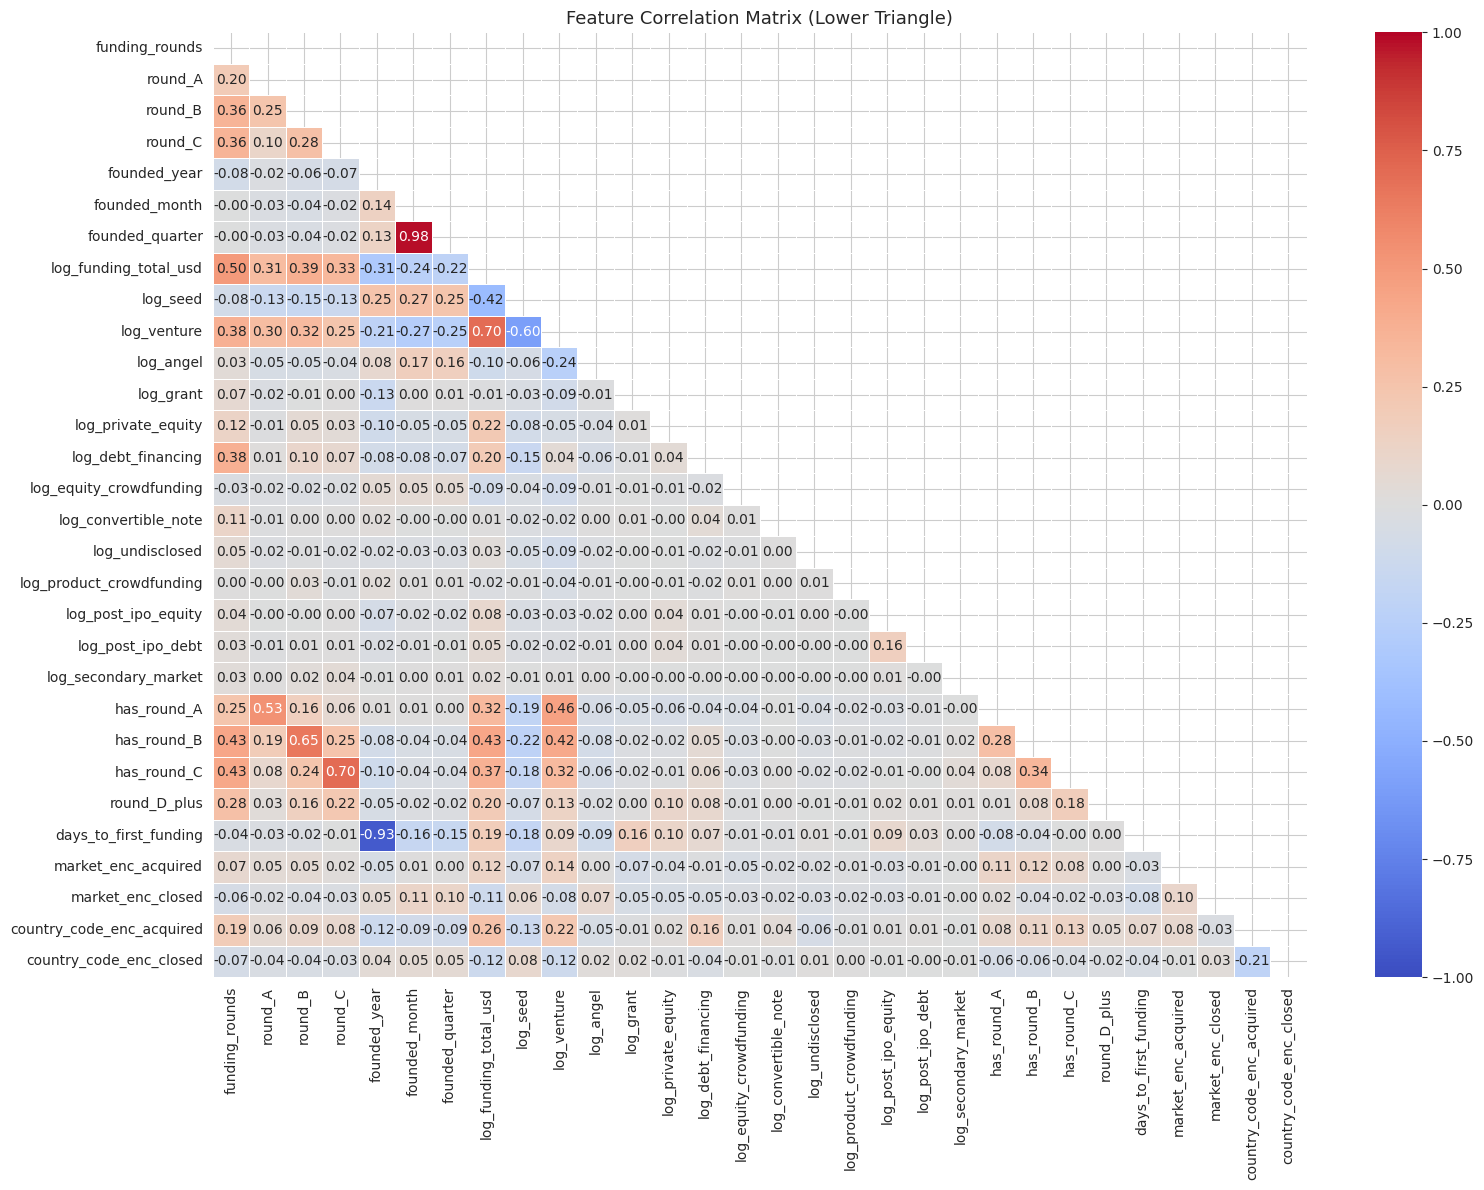

In [11]:
correlation_matrix = X_train.corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, mask=mask, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix (Lower Triangle)', fontsize=13)
plt.tight_layout()
plt.show()

In [12]:
CORRELATION_THRESHOLD = 0.75

corr_abs = correlation_matrix.abs()
upper_tri = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))

to_drop_corr = [col for col in upper_tri.columns if any(upper_tri[col] > CORRELATION_THRESHOLD)]

print(f"Correlation threshold: {CORRELATION_THRESHOLD}")
print(f"Original features:   {X_train.shape[1]}")
print(f"Features to drop:    {to_drop_corr}")
print(f"Remaining features:  {X_train.shape[1] - len(to_drop_corr)}")

Correlation threshold: 0.75
Original features:   30
Features to drop:    ['founded_quarter', 'days_to_first_funding']
Remaining features:  28


> **→ Modeling Decision:** Features with pairwise correlation > 0.7 are candidates for removal. We note which features are collinear and consider dropping the one with the lower ANOVA F-value in the final selection.

## 5. Model-Based Feature Importance (Wrapper Methods)

Wrapper methods evaluate feature importance **through model training**. Each method uses a different mechanism:

| Method | Mechanism |
|--------|-----------|
| **Random Forest** | Mean impurity decrease (Gini) across trees |
| **Gradient Boosting** | Feature usage frequency × gain in all trees |
| **Lasso (L1)** | Shrinks less-useful coefficients to exactly zero |
| **Ridge (L2)** | Shrinks coefficients toward zero — retains all features |
| **Linear SVM (L1)** | Sparse weight vector via L1 penalty |

In [13]:
# --- Random Forest ---
rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
rf_selected = (rf.feature_importances_ > 0).astype(int)
print(f"Random Forest — features with importance > 0: {rf_selected.sum()}")

Random Forest — features with importance > 0: 30


In [18]:
# --- Gradient Boosting ---
gb = GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE)
gb.fit(X_train, y_train)
gb_selected = (gb.feature_importances_ > 0).astype(int)
print(f"Gradient Boosting — features with importance > 0: {gb_selected.sum()}")

Gradient Boosting — features with importance > 0: 30


In [15]:
# --- Lasso (L1) ---
# Lasso performs feature selection by zeroing out less-relevant coefficients.
# Higher alpha = stronger penalty = more features zeroed out.
lasso = LogisticRegression(penalty='l1', solver='saga', C=0.1,
                            random_state=RANDOM_STATE, max_iter=2000,
                            multi_class='ovr')
lasso.fit(X_train, y_train)
# For multiclass: a feature is selected if any class has a non-zero coefficient
lasso_selected = (np.abs(lasso.coef_).sum(axis=0) > 1e-6).astype(int)
print(f"Lasso (L1 Logistic) — features selected: {lasso_selected.sum()}")

Lasso (L1 Logistic) — features selected: 0


In [16]:
# --- Ridge (L2) ---
# Ridge shrinks coefficients toward zero but rarely sets them exactly to zero.
# Useful for identifying relatively less informative features (very low coefs).
ridge = LogisticRegression(penalty='l2', solver='lbfgs', C=1.0,
                            random_state=RANDOM_STATE, max_iter=2000,
                            multi_class='ovr')
ridge.fit(X_train, y_train)
# Select features whose total absolute coefficient across classes is above median
ridge_coef_sum = np.abs(ridge.coef_).sum(axis=0)
ridge_selected = (ridge_coef_sum > np.median(ridge_coef_sum)).astype(int)
print(f"Ridge (L2 Logistic) — features above median coef magnitude: {ridge_selected.sum()}")

Ridge (L2 Logistic) — features above median coef magnitude: 15


In [17]:
# --- Linear SVM with L1 penalty ---
# LinearSVC with L1 penalty produces sparse weight vectors (feature selection).
svm = LinearSVC(C=0.1, penalty='l1', dual=False, random_state=RANDOM_STATE, max_iter=3000)
svm.fit(X_train, y_train)
svm_selected = (np.abs(svm.coef_).sum(axis=0) > 1e-6).astype(int)
print(f"Linear SVM (L1) — features selected: {svm_selected.sum()}")

Linear SVM (L1) — features selected: 26


## 6. Forward Sequential Feature Selection

Forward selection greedily adds the feature that most improves cross-validated performance at each step.  
It captures **feature interactions** that filter methods miss.

In [22]:
# Lightweight base estimator for sequential search
sfs_estimator = RandomForestClassifier(
    n_estimators=30,        # was 100 — enough for selection, not final modeling
    max_depth=8,            # cap depth to speed up each fit
    random_state=RANDOM_STATE,
    n_jobs=-1
)

sfs = SequentialFeatureSelector(
    sfs_estimator,
    n_features_to_select=10,   # was 'auto' — set a fixed cap instead of open-ended
    direction='forward',
    scoring='f1_macro',
    cv=3,
    n_jobs=-1
)
sfs.fit(X_train, y_train)

forward_selected = sfs.get_support().astype(int)
forward_features = X_train.columns[sfs.get_support()].tolist()
print(f"Forward Selection — features selected ({len(forward_features)}): {forward_features}")

Forward Selection — features selected (10): ['funding_rounds', 'round_A', 'founded_year', 'founded_quarter', 'log_funding_total_usd', 'log_seed', 'days_to_first_funding', 'market_enc_acquired', 'market_enc_closed', 'country_code_enc_acquired']


## 7. Permutation Importance

Permutation Importance measures how much the model's performance **drops** when a single feature's values are randomly shuffled.  
- A large drop → the model relied heavily on that feature.
- Advantage over built-in importance: works for any fitted model and captures the actual prediction impact.

In [25]:
# Permutation importance — using a small subsample of val for speed
# Full val set with n_repeats=15 is very slow; 500 rows × 5 repeats gives
# a stable enough ranking for a one-vote-in-eight selection signal.
VAL_SAMPLE = min(500, len(X_val))
idx = np.random.default_rng(RANDOM_STATE).choice(len(X_val), VAL_SAMPLE, replace=False)
X_val_pfi = X_val.iloc[idx]
y_val_pfi  = y_val.iloc[idx]

perm = permutation_importance(
    rf, X_val_pfi, y_val_pfi,
    n_repeats=5,
    scoring='f1_macro',
    random_state=RANDOM_STATE,
    n_jobs=1              # was -1 — runs in-process, no disk temp files
)

pfi_df = pd.DataFrame({
    'Feature':  X_train.columns,
    'PFI Mean': perm.importances_mean,
    'PFI Std':  perm.importances_std,
}).sort_values('PFI Mean', ascending=False).reset_index(drop=True)

pfi_selected = (perm.importances_mean > 0).astype(int)

print(f"Permutation importance computed on {VAL_SAMPLE} validation samples, 5 repeats.")
display(pfi_df.round(5))

Permutation importance computed on 500 validation samples, 5 repeats.


,Feature,PFI Mean,PFI Std
0,founded_year,0.07046,0.01832
1,funding_rounds,0.02950,0.00852
2,days_to_first_funding,0.02840,0.01938
3,log_venture,0.02552,0.02400
4,round_C,0.01784,0.00449
5,founded_month,0.01704,0.00521
6,log_seed,0.01054,0.00686
7,log_funding_total_usd,0.00992,0.01827
8,country_code_enc_acquired,0.00602,0.01882
9,founded_quarter,0.00345,0.00578


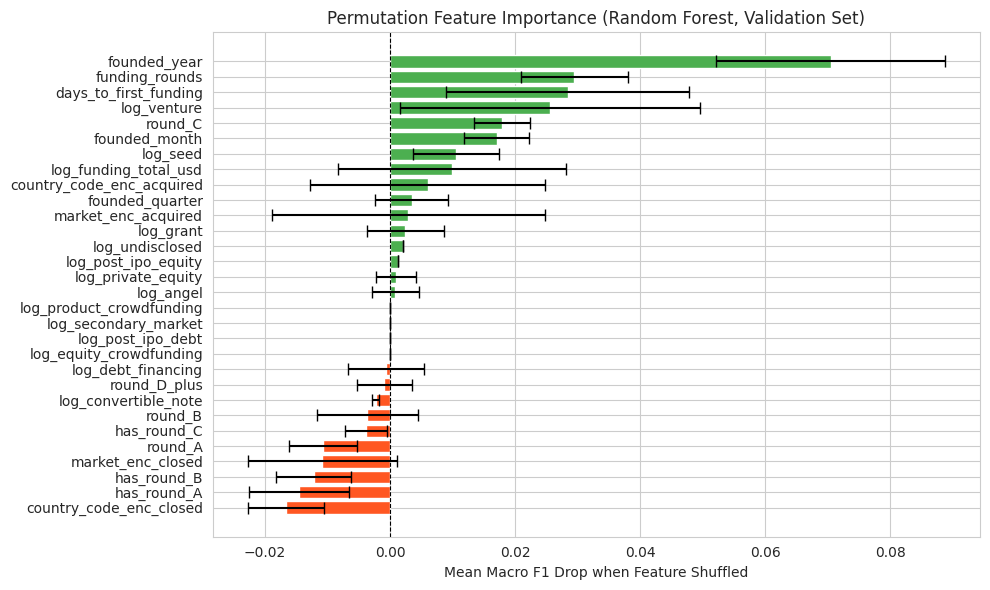

In [26]:
pfi_sorted = pfi_df.sort_values('PFI Mean', ascending=True)
bar_colors = ['#4CAF50' if v > 0 else '#FF5722' for v in pfi_sorted['PFI Mean']]

plt.figure(figsize=(10, 6))
plt.barh(pfi_sorted['Feature'], pfi_sorted['PFI Mean'],
         xerr=pfi_sorted['PFI Std'], color=bar_colors, edgecolor='white', capsize=4)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Permutation Feature Importance (Random Forest, Validation Set)', fontsize=12)
plt.xlabel('Mean Macro F1 Drop when Feature Shuffled')
plt.tight_layout()
plt.show()

## 8. Feature Selection Voting — Aggregated Results

We combine all selection signals into a single vote table.  
Features consistently selected across multiple methods are the most reliable.

In [27]:
selection_df = pd.DataFrame({
    'Feature':       X_train.columns,
    'ANOVA':         anova_selected,
    'Lasso':         lasso_selected,
    'SVM':           svm_selected,
    'GradientBoost': gb_selected,
    'RandomForest':  rf_selected,
    'Ridge':         ridge_selected,
    'Forward':       forward_selected,
    'PFI':           pfi_selected,
})

vote_cols = ['ANOVA', 'Lasso', 'SVM', 'GradientBoost', 'RandomForest', 'Ridge', 'Forward', 'PFI']
selection_df['Sum'] = selection_df[vote_cols].sum(axis=1)
selection_df = selection_df.sort_values('Sum', ascending=False).reset_index(drop=True)

display(selection_df)

,Feature,ANOVA,Lasso,SVM,GradientBoost,RandomForest,Ridge,Forward,PFI,Sum
0,funding_rounds,1,0,1,1,1,1,1,1,7
1,founded_quarter,1,0,1,1,1,1,1,1,7
2,log_funding_total_usd,1,0,1,1,1,1,1,1,7
3,log_seed,1,0,1,1,1,1,1,1,7
4,founded_year,1,0,1,1,1,0,1,1,6
5,founded_month,1,0,1,1,1,1,0,1,6
6,log_angel,1,0,1,1,1,1,0,1,6
7,log_venture,1,0,1,1,1,1,0,1,6
8,country_code_enc_acquired,1,0,1,1,1,0,1,1,6
9,market_enc_acquired,1,0,1,1,1,0,1,1,6


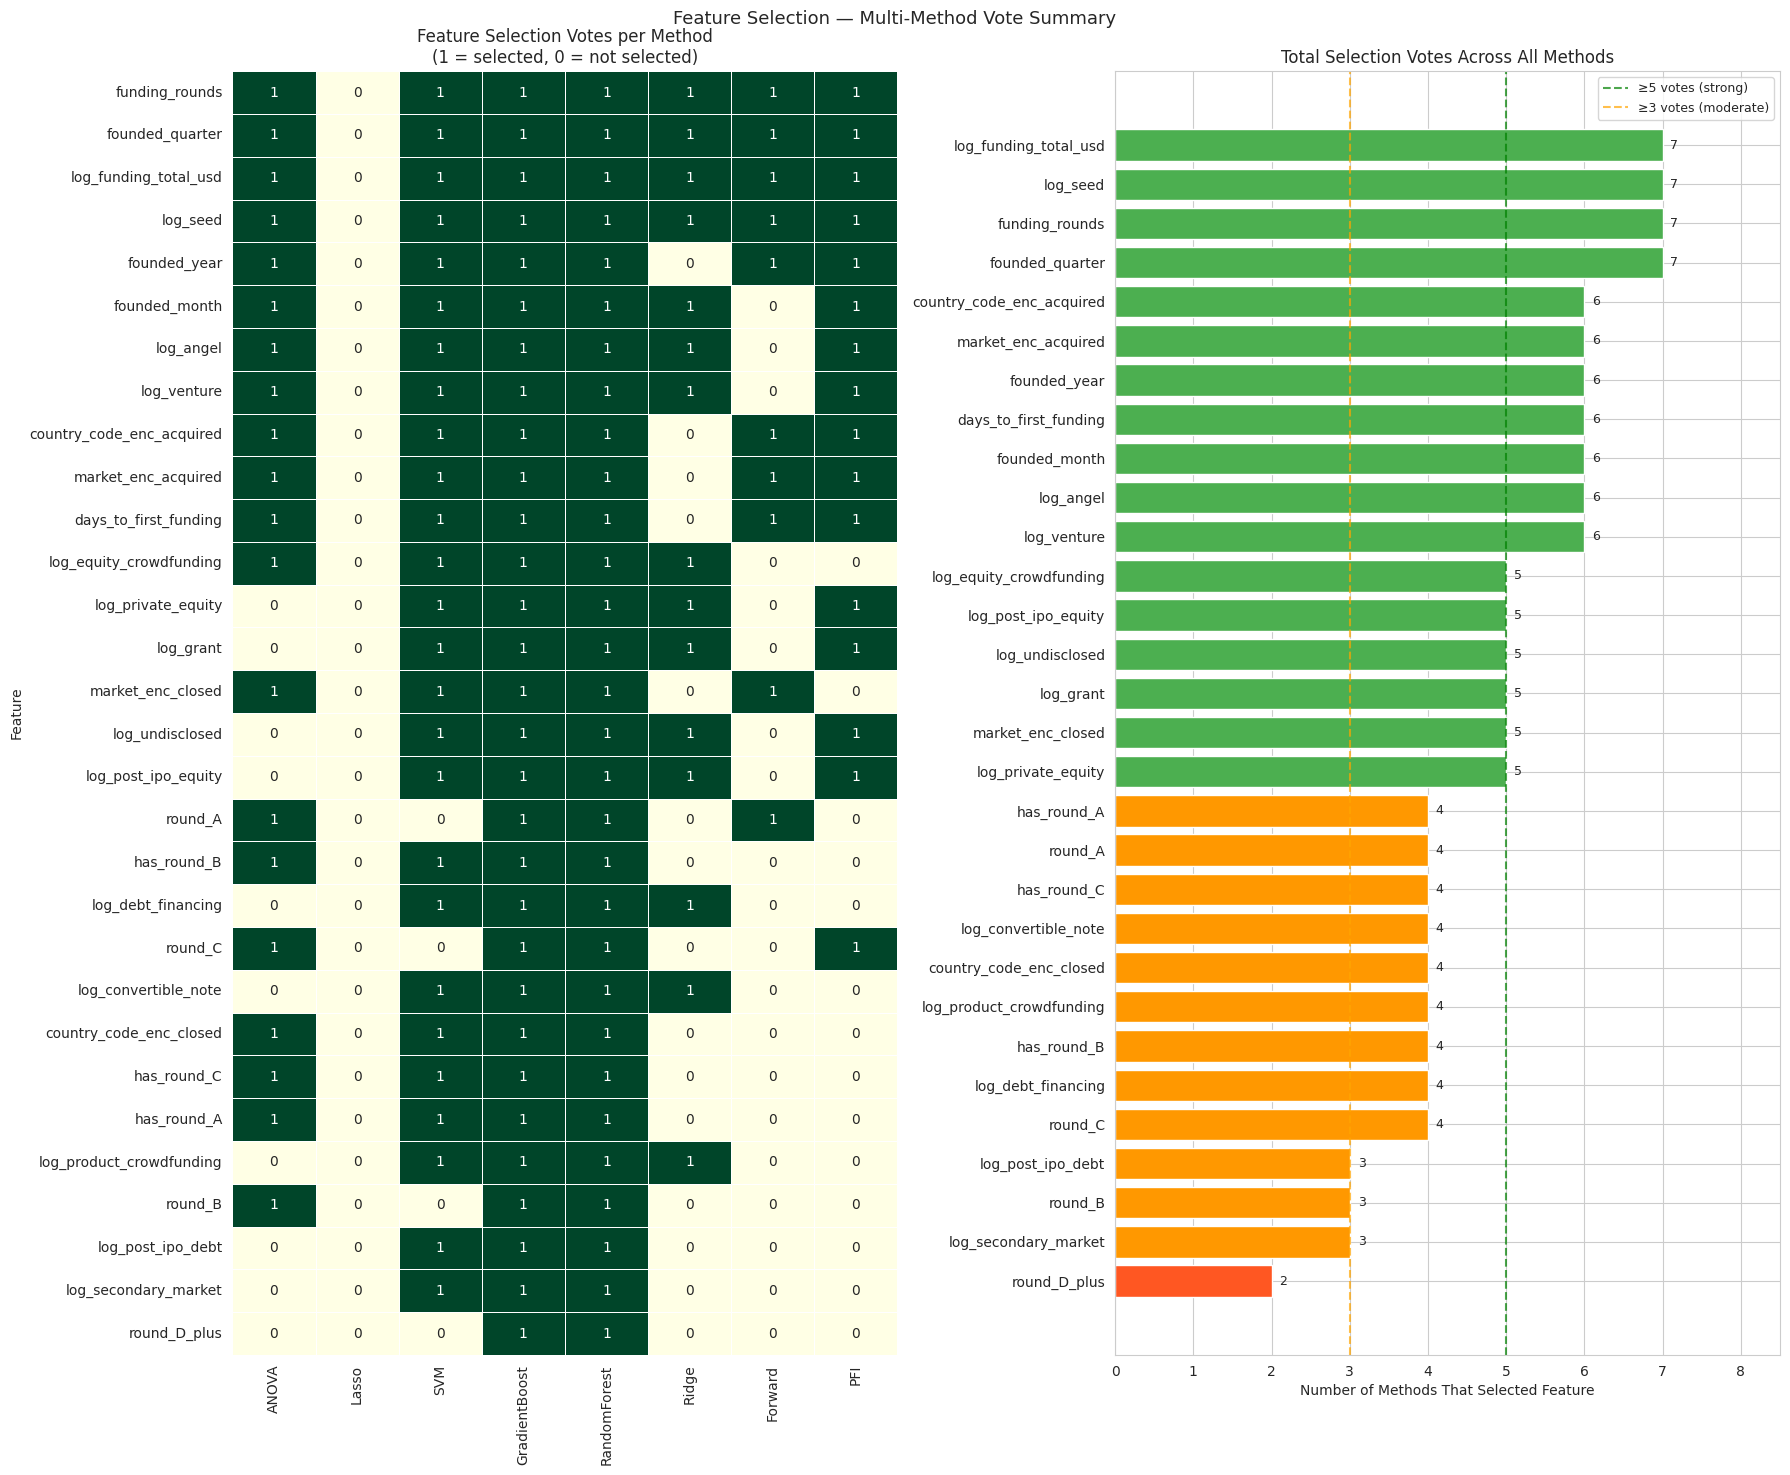

In [28]:
# Heatmap of selection votes
fig, axes = plt.subplots(1, 2, figsize=(18, max(6, len(X_train.columns) * 0.5)))

# Heatmap
heatmap_data = selection_df.set_index('Feature')[vote_cols]
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlGn',
            linewidths=0.5, ax=axes[0], cbar=False,
            vmin=0, vmax=1)
axes[0].set_title('Feature Selection Votes per Method\n(1 = selected, 0 = not selected)')
axes[0].set_xlabel('')

# Bar chart of total votes
sorted_sel = selection_df.sort_values('Sum', ascending=True)
bar_c = ['#4CAF50' if s >= 5 else '#FF9800' if s >= 3 else '#FF5722'
         for s in sorted_sel['Sum']]
axes[1].barh(sorted_sel['Feature'], sorted_sel['Sum'], color=bar_c, edgecolor='white')
axes[1].axvline(5, color='green',  linestyle='--', label='≥5 votes (strong)', alpha=0.7)
axes[1].axvline(3, color='orange', linestyle='--', label='≥3 votes (moderate)', alpha=0.7)
axes[1].set_title('Total Selection Votes Across All Methods')
axes[1].set_xlabel('Number of Methods That Selected Feature')
axes[1].set_xlim(0, len(vote_cols) + 0.5)
axes[1].legend(fontsize=9)
for i, v in enumerate(sorted_sel['Sum']):
    axes[1].text(v + 0.1, i, str(v), va='center', fontsize=9)

plt.suptitle('Feature Selection — Multi-Method Vote Summary', fontsize=13)
plt.tight_layout()
plt.show()

In [29]:
# Select features recommended by >= VOTE_THRESHOLD methods
VOTE_THRESHOLD = 5

selected_features = selection_df[selection_df['Sum'] >= VOTE_THRESHOLD]['Feature'].tolist()
all_features      = X_train.columns.tolist()

print(f"Vote threshold: {VOTE_THRESHOLD} / {len(vote_cols)} methods")
print(f"Selected features ({len(selected_features)}): {selected_features}")
print(f"Dropped features  ({len(all_features) - len(selected_features)}): "
      f"{[f for f in all_features if f not in selected_features]}")

# Build filtered datasets
X_train_sel = X_train[selected_features]
X_val_sel   = X_val[selected_features]
X_test_sel  = X_test[selected_features]

Vote threshold: 5 / 8 methods
Selected features (17): ['funding_rounds', 'founded_quarter', 'log_funding_total_usd', 'log_seed', 'founded_year', 'founded_month', 'log_angel', 'log_venture', 'country_code_enc_acquired', 'market_enc_acquired', 'days_to_first_funding', 'log_equity_crowdfunding', 'log_private_equity', 'log_grant', 'market_enc_closed', 'log_undisclosed', 'log_post_ipo_equity']
Dropped features  (13): ['round_A', 'round_B', 'round_C', 'log_debt_financing', 'log_convertible_note', 'log_product_crowdfunding', 'log_post_ipo_debt', 'log_secondary_market', 'has_round_A', 'has_round_B', 'has_round_C', 'round_D_plus', 'country_code_enc_closed']


> **→ Modeling Decision:** Features selected by ≥ 5 of 8 methods form our **selected feature set**. We will compare models trained on the **full feature set** vs the **selected feature set** to confirm the selection improves or maintains performance.

---
# Part B — Modeling with Regularization

We train five model families with built-in or explicit regularization and compare them on the validation set using **Macro F1** as the primary criterion.

| Model | Regularization mechanism |
|-------|-------------------------|
| Logistic Regression (L2) | Ridge penalty on coefficients |
| Logistic Regression (L1) | Lasso penalty — sparse coefficients |
| Random Forest | Bagging + max_features sub-sampling |
| Gradient Boosting | Shrinkage (learning rate) + subsampling |
| XGBoost | L1/L2 weight regularization + column/row sub-sampling |

## 9. Train Models — Full vs Selected Features

In [30]:
models = {
    'LR (L2)': LogisticRegression(
        penalty='l2', C=1.0, solver='lbfgs',
        multi_class='multinomial', max_iter=2000,
        random_state=RANDOM_STATE
    ),
    'LR (L1)': LogisticRegression(
        penalty='l1', C=0.5, solver='saga',
        multi_class='ovr', max_iter=2000,
        random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=12,
        max_features='sqrt', min_samples_leaf=3,
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=300, max_depth=5,
        learning_rate=0.05, subsample=0.8,
        random_state=RANDOM_STATE
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=5,
        learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,  # L1 + L2 regularization
        eval_metric='mlogloss', verbosity=0,
        random_state=RANDOM_STATE
    ),
}

In [31]:
results_full = []
results_sel  = []

fitted_full = {}
fitted_sel  = {}

for name, model in models.items():
    import copy

    # --- Full features ---
    m_full = copy.deepcopy(model)
    m_full.fit(X_train, y_train)
    y_pred_full = m_full.predict(X_val)
    results_full.append(classification_metrics(y_val, y_pred_full, f'{name} [all features]'))
    fitted_full[name] = m_full

    # --- Selected features ---
    m_sel = copy.deepcopy(model)
    m_sel.fit(X_train_sel, y_train)
    y_pred_sel = m_sel.predict(X_val_sel)
    results_sel.append(classification_metrics(y_val, y_pred_sel, f'{name} [selected features]'))
    fitted_sel[name] = m_sel

    print(f"{name:25s} | Full Macro F1: {results_full[-1]['Macro F1']:.4f} "
          f"| Selected Macro F1: {results_sel[-1]['Macro F1']:.4f}")

LR (L2)                   | Full Macro F1: 0.2229 | Selected Macro F1: 0.3349
LR (L1)                   | Full Macro F1: 0.3310 | Selected Macro F1: 0.1733
Random Forest             | Full Macro F1: 0.4929 | Selected Macro F1: 0.4895
Gradient Boosting         | Full Macro F1: 0.4764 | Selected Macro F1: 0.4666
XGBoost                   | Full Macro F1: 0.4898 | Selected Macro F1: 0.4753


In [32]:
results_all_df = pd.DataFrame(results_full + results_sel).set_index('Model')
display(results_all_df.round(4).sort_values('Macro F1', ascending=False))

,Accuracy,Macro F1,Weighted F1,F1 closed,F1 operating,F1 acquired
Model,,,,,,
Random Forest [all features],0.7655,0.4929,0.7923,0.2585,0.8668,0.3535
XGBoost [all features],0.8317,0.4898,0.8255,0.2466,0.9097,0.3133
Random Forest [selected features],0.7670,0.4895,0.7922,0.2660,0.8680,0.3346
Gradient Boosting [all features],0.8416,0.4764,0.8282,0.2141,0.9163,0.2988
XGBoost [selected features],0.8292,0.4753,0.8212,0.2371,0.9084,0.2802
Gradient Boosting [selected features],0.8399,0.4666,0.8248,0.2240,0.9153,0.2605
LR (L2) [selected features],0.4385,0.3349,0.5270,0.1594,0.5740,0.2712
LR (L1) [all features],0.4634,0.3310,0.5523,0.1369,0.6067,0.2494
LR (L2) [all features],0.2281,0.2229,0.2877,0.1132,0.3018,0.2536


## 10. Model Comparison — Validation Set

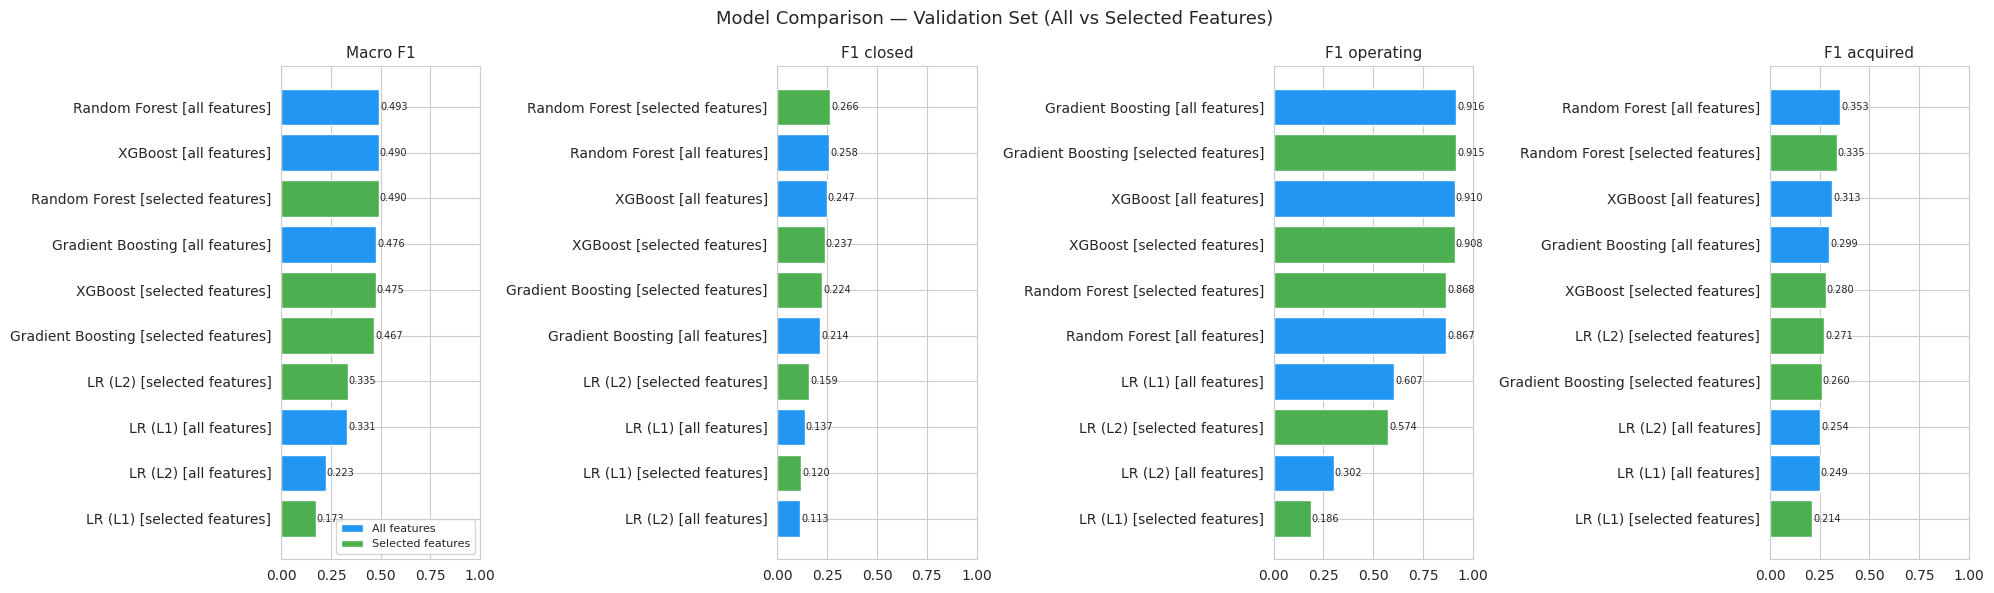

In [33]:
metrics_to_plot = ['Macro F1', 'F1 closed', 'F1 operating', 'F1 acquired']
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(20, 6))

for ax, metric in zip(axes, metrics_to_plot):
    vals = results_all_df[metric].sort_values(ascending=True)
    bar_cols = ['#2196F3' if 'all' in t else '#4CAF50' for t in vals.index]
    ax.barh(vals.index, vals.values, color=bar_cols, edgecolor='white')
    ax.set_title(metric, fontsize=11)
    ax.set_xlim(0, 1)
    for i, v in enumerate(vals.values):
        ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=7)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2196F3', label='All features'),
                   Patch(facecolor='#4CAF50', label='Selected features')]
axes[0].legend(handles=legend_elements, loc='lower right', fontsize=8)

plt.suptitle('Model Comparison — Validation Set (All vs Selected Features)', fontsize=13)
plt.tight_layout()
plt.show()

## 11. Regularization Sensitivity Analysis (XGBoost)

We sweep the XGBoost regularization parameters (`reg_alpha` for L1, `reg_lambda` for L2) to understand their effect on validation Macro F1.

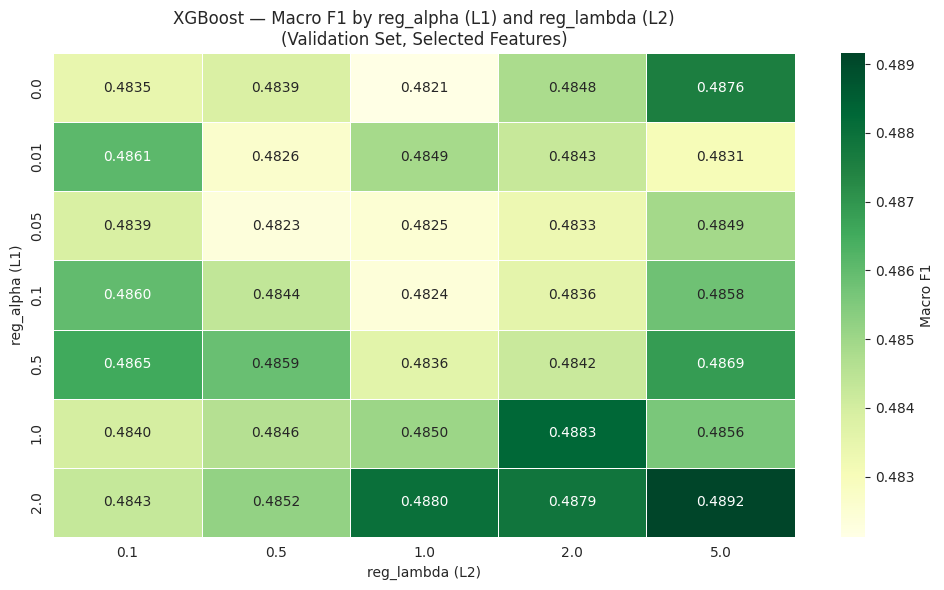


Best regularization: reg_alpha=2.0, reg_lambda=5.0  →  Macro F1=0.4892


In [34]:
alphas  = [0, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0]
lambdas = [0.1, 0.5, 1.0, 2.0, 5.0]

reg_results = []
for alpha in alphas:
    for lam in lambdas:
        m = XGBClassifier(
            n_estimators=200, max_depth=5, learning_rate=0.05,
            reg_alpha=alpha, reg_lambda=lam,
            eval_metric='mlogloss', verbosity=0, random_state=RANDOM_STATE
        )
        m.fit(X_train_sel, y_train)
        y_pred = m.predict(X_val_sel)
        reg_results.append({
            'reg_alpha':  alpha,
            'reg_lambda': lam,
            'Macro F1':   f1_score(y_val, y_pred, average='macro')
        })

reg_df = pd.DataFrame(reg_results)
pivot  = reg_df.pivot(index='reg_alpha', columns='reg_lambda', values='Macro F1')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGn', linewidths=0.5,
            cbar_kws={'label': 'Macro F1'})
plt.title('XGBoost — Macro F1 by reg_alpha (L1) and reg_lambda (L2)\n(Validation Set, Selected Features)', fontsize=12)
plt.xlabel('reg_lambda (L2)')
plt.ylabel('reg_alpha (L1)')
plt.tight_layout()
plt.show()

best_reg = reg_df.loc[reg_df['Macro F1'].idxmax()]
print(f"\nBest regularization: reg_alpha={best_reg['reg_alpha']}, "
      f"reg_lambda={best_reg['reg_lambda']}  →  Macro F1={best_reg['Macro F1']:.4f}")

> **→ Modeling Decision:** The heatmap reveals the optimal regularization region. We use the best `(reg_alpha, reg_lambda)` pair for our final model.

## 12. Final Model Selection & Confusion Matrices

In [35]:
# Best model by Macro F1 on validation set
best_model_name = results_all_df['Macro F1'].idxmax()
print(f"Best model: {best_model_name}")
print(f"Macro F1 (val): {results_all_df.loc[best_model_name, 'Macro F1']:.4f}")

# Retrieve best fitted model
is_selected = 'selected' in best_model_name
base_name   = best_model_name.replace(' [all features]', '').replace(' [selected features]', '')
best_fitted = fitted_sel[base_name] if is_selected else fitted_full[base_name]
X_val_best  = X_val_sel if is_selected else X_val
X_test_best = X_test_sel if is_selected else X_test

y_pred_best_val = best_fitted.predict(X_val_best)

Best model: Random Forest [all features]
Macro F1 (val): 0.4929


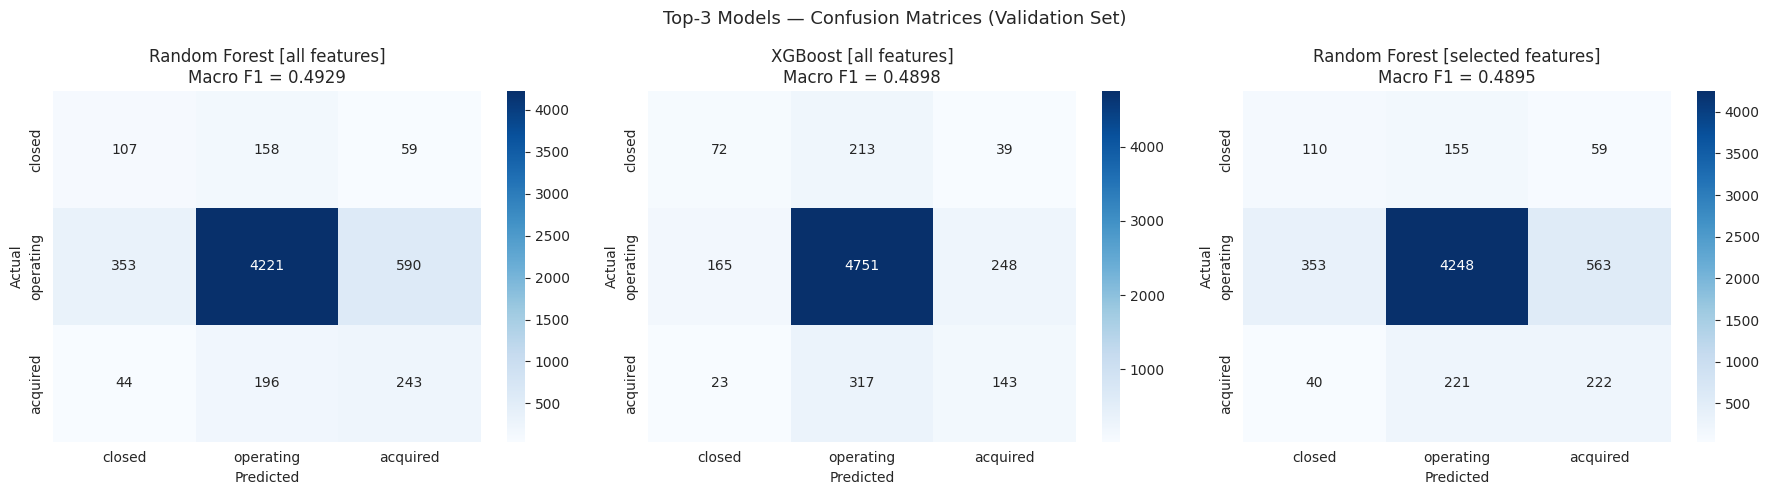

In [36]:
# Top-3 models side-by-side confusion matrices
top3 = results_all_df['Macro F1'].sort_values(ascending=False).head(3)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (mname, _) in zip(axes, top3.items()):
    _is_sel   = 'selected' in mname
    _base     = mname.replace(' [all features]', '').replace(' [selected features]', '')
    _fitted   = fitted_sel[_base] if _is_sel else fitted_full[_base]
    _X_val    = X_val_sel if _is_sel else X_val
    _y_pred   = _fitted.predict(_X_val)
    _f1       = f1_score(y_val, _y_pred, average='macro')
    plot_confusion_matrix(y_val, _y_pred,
                          title=f"{mname}\nMacro F1 = {_f1:.4f}", ax=ax)

plt.suptitle('Top-3 Models — Confusion Matrices (Validation Set)', fontsize=13)
plt.tight_layout()
plt.show()

## 13. ROC Curves — Best Model (Validation Set)

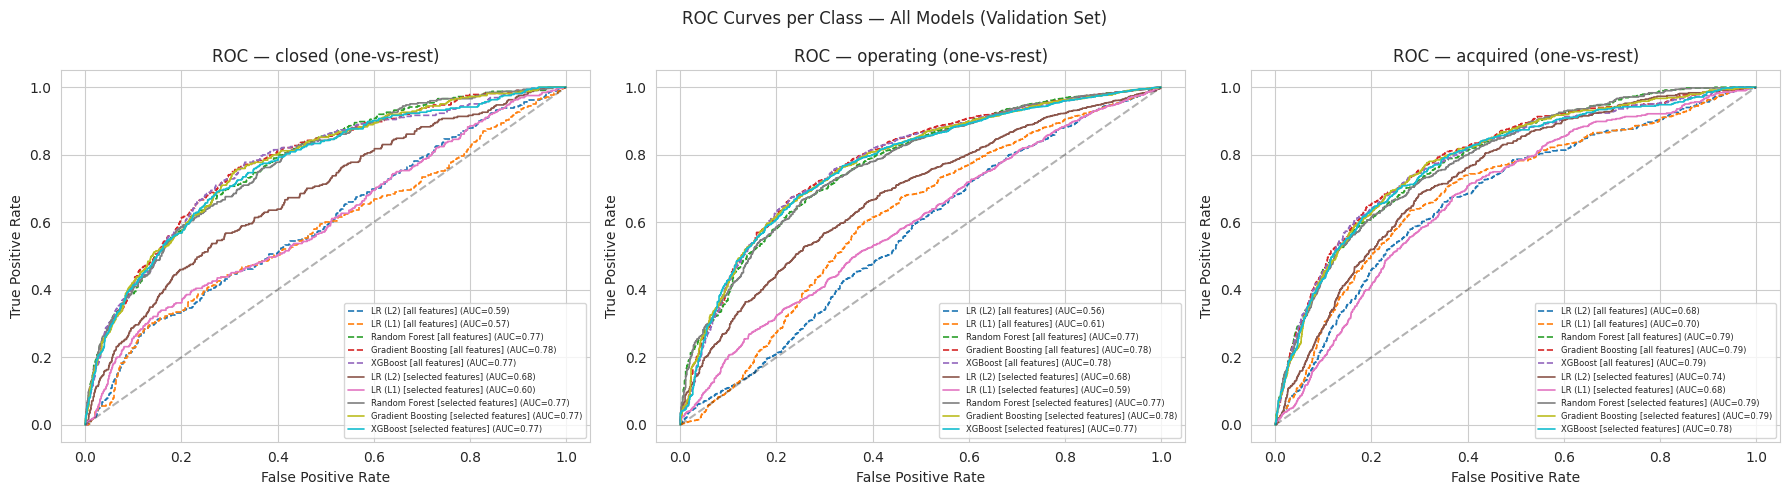

In [37]:
y_val_bin = label_binarize(y_val, classes=[0, 1, 2])  # (n, 3)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for cls_idx, (cls_name, color) in enumerate(zip(STATUS_NAMES, COLORS)):
    ax = axes[cls_idx]

    # Plot all models
    for mname in results_all_df.index:
        _is_sel = 'selected' in mname
        _base   = mname.replace(' [all features]', '').replace(' [selected features]', '')
        _fitted = fitted_sel[_base] if _is_sel else fitted_full[_base]
        _X_val  = X_val_sel if _is_sel else X_val

        try:
            proba = _fitted.predict_proba(_X_val)[:, cls_idx]
            fpr, tpr, _ = roc_curve(y_val_bin[:, cls_idx], proba)
            roc_auc = auc(fpr, tpr)
            linestyle = '-' if _is_sel else '--'
            ax.plot(fpr, tpr, linestyle=linestyle,
                    label=f"{mname} (AUC={roc_auc:.2f})",
                    linewidth=1.2)
        except AttributeError:
            pass  # LinearSVC has no predict_proba

    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_title(f'ROC — {cls_name} (one-vs-rest)')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=6)
    ax.grid(True)

plt.suptitle('ROC Curves per Class — All Models (Validation Set)', fontsize=12)
plt.tight_layout()
plt.show()

## 14. Full Validation Report — Best Model

Best model: Random Forest [all features]
Feature set: all (30 features)

              precision    recall  f1-score   support

      closed       0.21      0.33      0.26       324
   operating       0.92      0.82      0.87      5164
    acquired       0.27      0.50      0.35       483

    accuracy                           0.77      5971
   macro avg       0.47      0.55      0.49      5971
weighted avg       0.83      0.77      0.79      5971



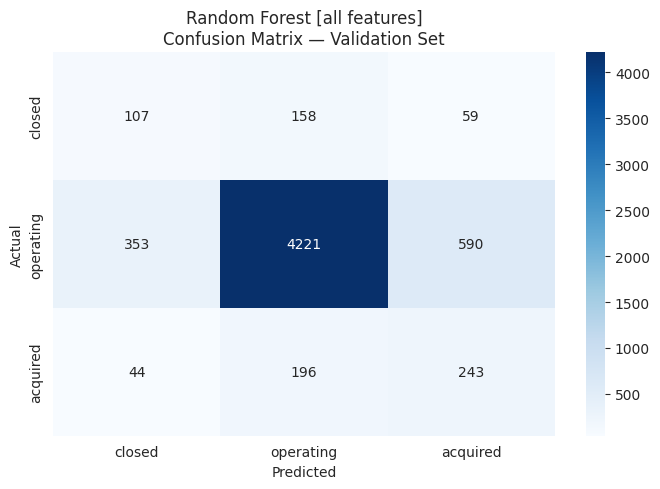

In [38]:
print(f"Best model: {best_model_name}")
print(f"Feature set: {'selected' if is_selected else 'all'} "
      f"({len(selected_features) if is_selected else len(all_features)} features)")
print()
print(classification_report(y_val, y_pred_best_val, target_names=STATUS_NAMES))

fig, ax = plt.subplots(figsize=(7, 5))
plot_confusion_matrix(y_val, y_pred_best_val,
                      title=f'{best_model_name}\nConfusion Matrix — Validation Set', ax=ax)
plt.tight_layout()
plt.show()

## 15. Final Evaluation on Test Set

> ⚠️ **Run this cell only once.** The test set is touched here for the first time in this notebook. Using it during model/feature selection would leak information.

 FINAL TEST SET RESULTS — Random Forest [all features]
              precision    recall  f1-score   support

      closed       0.22      0.34      0.26       324
   operating       0.92      0.81      0.86      5164
    acquired       0.23      0.42      0.30       483

    accuracy                           0.76      5971
   macro avg       0.45      0.52      0.47      5971
weighted avg       0.82      0.76      0.78      5971



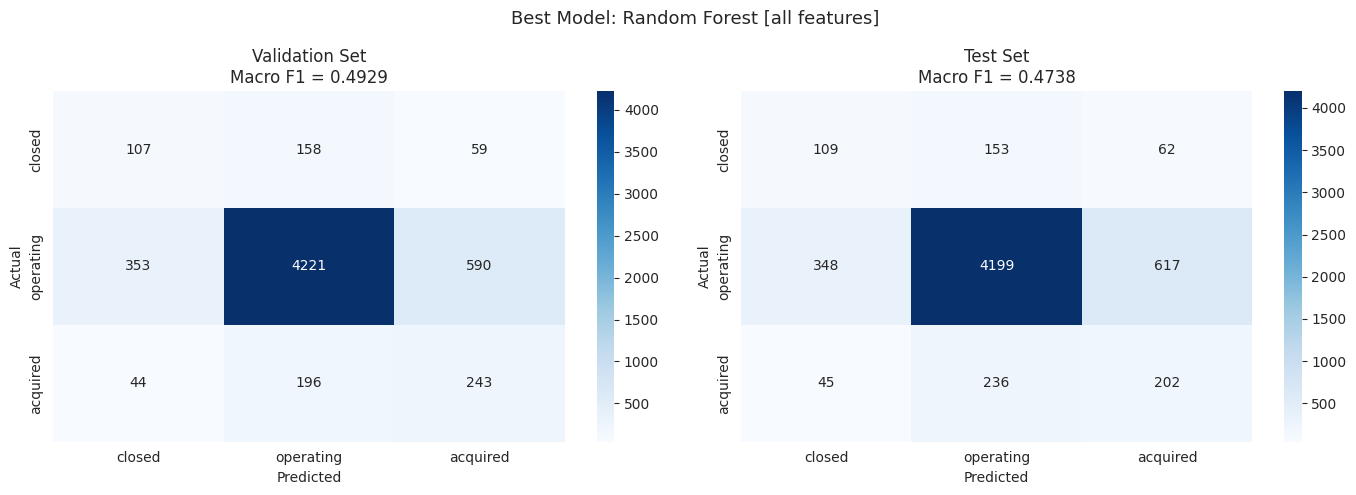

In [40]:
y_pred_test = best_fitted.predict(X_test_best)

print("="*55)
print(f" FINAL TEST SET RESULTS — {best_model_name}")
print("="*55)
print(classification_report(y_test, y_pred_test, target_names=STATUS_NAMES))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Validation CM
plot_confusion_matrix(y_val, y_pred_best_val,
                      title=f'Validation Set\nMacro F1 = {f1_score(y_val, y_pred_best_val, average="macro"):.4f}',
                      ax=axes[0])

# Test CM
plot_confusion_matrix(y_test, y_pred_test,
                      title=f'Test Set\nMacro F1 = {f1_score(y_test, y_pred_test, average="macro"):.4f}',
                      ax=axes[1])

plt.suptitle(f'Best Model: {best_model_name}', fontsize=13)
plt.tight_layout()
plt.show()

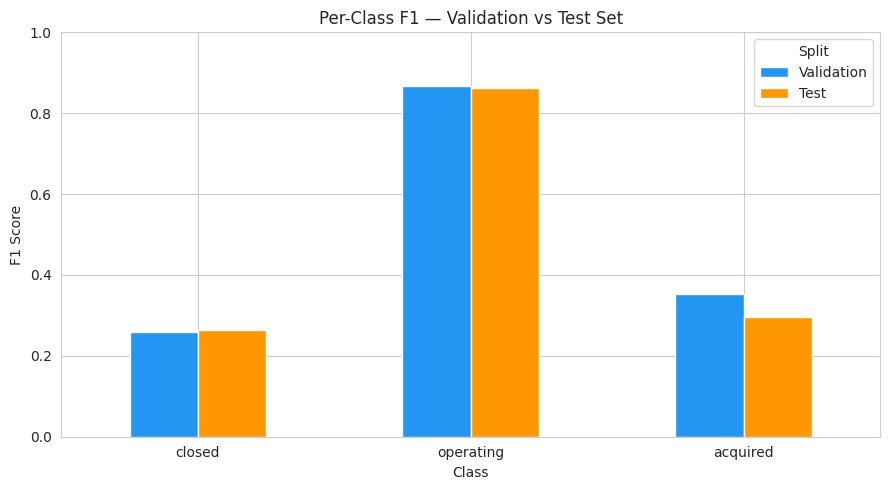

           Validation    Test
closed         0.2585  0.2639
operating      0.8668  0.8612
acquired       0.3535  0.2962


In [41]:
# Side-by-side per-class F1 — validation vs test
val_f1s  = f1_score(y_val,  y_pred_best_val, average=None, labels=[0, 1, 2])
test_f1s = f1_score(y_test, y_pred_test,     average=None, labels=[0, 1, 2])

compare_df = pd.DataFrame({
    'Validation': val_f1s,
    'Test':       test_f1s
}, index=STATUS_NAMES)

compare_df.plot(kind='bar', figsize=(9, 5),
                color=['#2196F3', '#FF9800'], edgecolor='white')
plt.title('Per-Class F1 — Validation vs Test Set')
plt.ylabel('F1 Score')
plt.xlabel('Class')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(title='Split')
plt.tight_layout()
plt.show()

print(compare_df.round(4))

> **→ Modeling Decision:** A small gap between validation and test Macro F1 is expected and healthy. A large gap would suggest the model is overfitted to the validation set (e.g., via excessive hyperparameter tuning on val). Our regularization and feature selection choices mitigate this risk.

## 16. Feature Importance — Best Tree Model

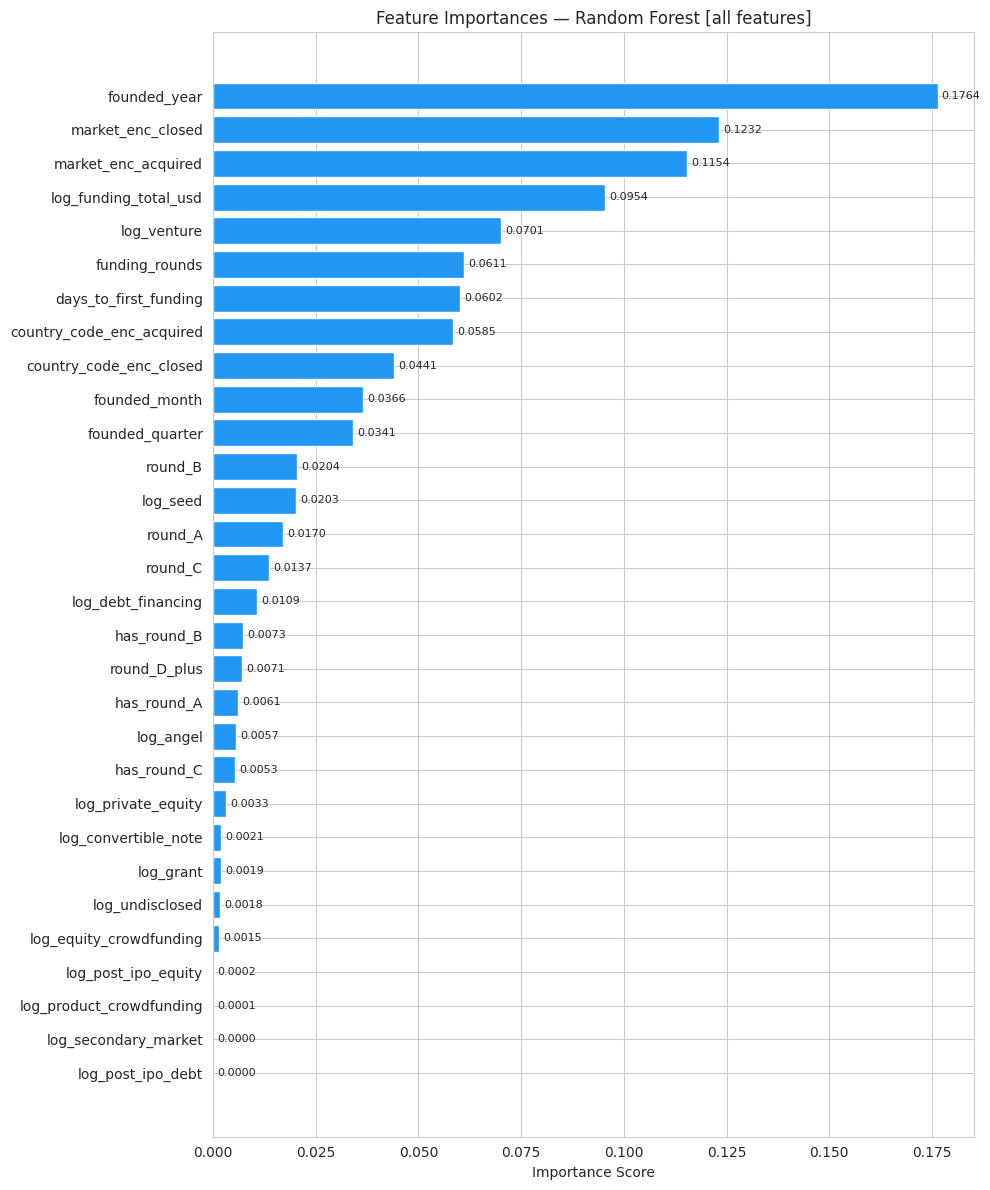

In [39]:
# Display feature importances if the best model supports them
feat_names = selected_features if is_selected else all_features

if hasattr(best_fitted, 'feature_importances_'):
    imp_df = pd.DataFrame({
        'Feature':    feat_names,
        'Importance': best_fitted.feature_importances_
    }).sort_values('Importance', ascending=True)

    plt.figure(figsize=(10, max(5, len(feat_names) * 0.4)))
    bars = plt.barh(imp_df['Feature'], imp_df['Importance'], color='#2196F3', edgecolor='white')
    plt.title(f'Feature Importances — {best_model_name}', fontsize=12)
    plt.xlabel('Importance Score')
    for bar, v in zip(bars, imp_df['Importance']):
        plt.text(v + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{v:.4f}', va='center', fontsize=8)
    plt.tight_layout()
    plt.show()

elif hasattr(best_fitted, 'coef_'):
    coef_mat = np.abs(best_fitted.coef_)
    imp_df = pd.DataFrame(coef_mat.T, index=feat_names, columns=STATUS_NAMES)
    imp_df['Mean |coef|'] = imp_df.mean(axis=1)
    imp_df = imp_df.sort_values('Mean |coef|', ascending=True)

    imp_df[STATUS_NAMES].plot(kind='barh', figsize=(12, max(5, len(feat_names) * 0.4)),
                              color=COLORS, edgecolor='white')
    plt.title(f'Coefficient Magnitudes — {best_model_name}', fontsize=12)
    plt.xlabel('|Coefficient|')
    plt.tight_layout()
    plt.show()

## Summary

### Feature Selection
| Step | Method | Outcome |
|------|--------|---------|
| Filter | ANOVA F-test + Chi-squared | Ranked features by statistical association with target |
| Correlation | Pearson correlation matrix | Identified collinear feature pairs |
| Wrapper (importance) | RF, GB, Lasso, Ridge, SVM | Binary selection votes per method |
| Wrapper (sequential) | Forward Selection (RF base, Macro F1) | Interaction-aware selection |
| Post-hoc | Permutation Importance on val set | Confirmed real predictive impact |
| **Aggregated** | **Vote ≥ 5 / 8 methods** | **Final selected feature set** |

### Modeling
| Step | Decision |
|------|----------|
| Models tested | LR (L1/L2), Random Forest, Gradient Boosting, XGBoost |
| Regularization sweep | XGBoost reg_alpha × reg_lambda grid |
| Feature comparison | All features vs selected features (vote ≥ 5) |
| Selection criterion | **Macro F1 on validation set** |
| Final evaluation | Test set (one-shot, post selection) |

### Output Files
| File | Description |
|------|-------------|
| `data/train_resampled.csv` | Resampled training set (from `04_Imbalanced_Data.ipynb`) |
| `data/val_processed.csv` | Validation set — unchanged throughout |
| `data/test_processed.csv` | Test set — used only for final evaluation in Section 15 |